# Airline Passenger Satisfaction — Hypothesis Testing

This notebook implements the approved protocol in `Hypothesis Testing.md`. The outcome is `is_satisfied` (1 = Satisfied; 0 = Neutral or Dissatisfied). All primary tests use α = 0.05, report effect sizes and 95% confidence intervals, and distinguish statistical association from causation.

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from patsy import build_design_matrices
from statsmodels.formula.api import glm
from statsmodels.genmod.families import Binomial
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
df = pd.read_csv(ROOT / "data/processed/airline_passenger_satisfaction_cleaned.csv")
ALPHA = 0.05
print(f"Loaded {len(df):,} records.")

Loaded 129,880 records.


In [2]:
def lr_test(full, reduced):
    statistic = 2 * (full.llf - reduced.llf)
    df_diff = int(full.df_model - reduced.df_model)
    return statistic, df_diff, stats.chi2.sf(statistic, df_diff)

def holm_frame(labels, raw_p):
    reject, adjusted, _, _ = multipletests(raw_p, alpha=ALPHA, method="holm")
    return pd.DataFrame({"Comparison": labels, "Raw p-value": raw_p, "Holm p-value": adjusted, "Reject H0": reject})

def odds_ratio_table(model, contains=None):
    ci = model.conf_int()
    out = pd.DataFrame({"Term": model.params.index, "Odds ratio": np.exp(model.params),
                        "CI low": np.exp(ci[0]), "CI high": np.exp(ci[1]), "p-value": model.pvalues})
    if contains:
        out = out[out["Term"].str.contains(contains, regex=True)]
    return out.reset_index(drop=True)

def standardized_probabilities(model, data, variable, values):
    result = []
    for value in values:
        scenario = data.copy()
        scenario[variable] = value
        design = np.asarray(build_design_matrices([model.model.data.design_info], scenario)[0])
        probability = model.family.link.inverse(design @ model.params.to_numpy())
        estimate = probability.mean()
        gradient = (probability * (1-probability))[:,None] * design
        average_gradient = gradient.mean(axis=0)
        variance = average_gradient @ model.cov_params().to_numpy() @ average_gradient
        standard_error = np.sqrt(max(variance, 0))
        result.append({"Level": value, "Predicted probability": estimate,
                       "CI low": max(0, estimate - 1.96*standard_error),
                       "CI high": min(1, estimate + 1.96*standard_error)})
    return pd.DataFrame(result)

def model_diagnostics(model, label):
    fitted = model.fittedvalues
    return {"Model": label, "N": int(model.nobs), "McFadden pseudo-R2": 1-model.llf/model.llnull,
            "Converged": bool(model.converged),
            "Min fitted probability": fitted.min(), "Max fitted probability": fitted.max(),
            "Deviance/df residual": model.deviance/model.df_resid}

## 1. Preliminary checks

Departure and arrival delays measure closely related portions of the same journey. Their correlation is checked before adjusted models; highly correlated versions are not included together in primary adjusted models.

In [3]:
delay_complete = df.dropna(subset=["arrival_delay"])
delay_corr = delay_complete[["departure_delay", "arrival_delay"]].corr().iloc[0,1]
sample_summary = pd.DataFrame({
    "Quantity": ["Full dataset", "Missing arrival delay", "Departure/arrival delay correlation"],
    "Value": [f"{len(df):,}", f"{df.arrival_delay.isna().sum():,}", f"{delay_corr:.3f}"]
})
display(sample_summary.style.hide(axis="index"))
display(Markdown(f"Departure and arrival delays correlate at **{delay_corr:.3f}**. Therefore, departure delay is used in the main adjusted models for Hypotheses 1 and 2; arrival delay replaces it in sensitivity models."))

Quantity,Value
Full dataset,"129,880"
Missing arrival delay,393
Departure/arrival delay correlation,0.965


Departure and arrival delays correlate at **0.965**. Therefore, departure delay is used in the main adjusted models for Hypotheses 1 and 2; arrival delay replaces it in sensitivity models.

## 2. Hypothesis 1 — Service quality and satisfaction

**Primary test:** likelihood-ratio comparison of a logistic model containing categorical cleanliness, seat-comfort, and onboard-service ratings against an intercept-only model. Clean fields exclude undocumented zero ratings.

In [4]:
h1_vars = ["cleanliness_rating_clean", "seat_comfort_rating_clean", "onboard_service_rating_clean"]
h1 = df.dropna(subset=h1_vars + ["is_satisfied"]).copy()
service_terms = [f"C({v}, Treatment(reference=1))" for v in h1_vars]
h1_formula = "is_satisfied ~ " + " + ".join(service_terms)
h1_full = glm(h1_formula, data=h1, family=Binomial()).fit()
h1_null = glm("is_satisfied ~ 1", data=h1, family=Binomial()).fit()
h1_lr, h1_df, h1_p = lr_test(h1_full, h1_null)
h1_primary = pd.DataFrame({"Analysis N":[len(h1)], "Excluded":[len(df)-len(h1)], "LR statistic":[h1_lr], "df":[h1_df], "p-value":[h1_p], "Decision":["Reject H0" if h1_p < ALPHA else "Fail to reject H0"]})
display(h1_primary.style.format({"Analysis N":"{:,}","Excluded":"{:,}","LR statistic":"{:.2f}","p-value":"{:.3e}"}).hide(axis="index"))
display(Markdown("**Rating-level odds ratios (reference = rating 1)**"))
display(odds_ratio_table(h1_full, "rating_clean").style.format({"Odds ratio":"{:.2f}","CI low":"{:.2f}","CI high":"{:.2f}","p-value":"{:.3e}"}).hide(axis="index"))

Analysis N,Excluded,LR statistic,df,p-value,Decision
"129,861",19,33591.61,12,0.000e+00,Reject H0


**Rating-level odds ratios (reference = rating 1)**

Term,Odds ratio,CI low,CI high,p-value
"C(cleanliness_rating_clean, Treatment(reference=1))[T.2.0]",1.10,1.03,1.18,3.540e-03
"C(cleanliness_rating_clean, Treatment(reference=1))[T.3.0]",2.68,2.52,2.84,3.726e-235
"C(cleanliness_rating_clean, Treatment(reference=1))[T.4.0]",2.29,2.16,2.43,1.658e-172
"C(cleanliness_rating_clean, Treatment(reference=1))[T.5.0]",2.50,2.35,2.65,7.197e-194
"C(seat_comfort_rating_clean, Treatment(reference=1))[T.2.0]",1.01,0.94,1.08,7.705e-01
"C(seat_comfort_rating_clean, Treatment(reference=1))[T.3.0]",0.58,0.55,0.62,9.288e-64
"C(seat_comfort_rating_clean, Treatment(reference=1))[T.4.0]",2.57,2.43,2.72,2.806e-228
"C(seat_comfort_rating_clean, Treatment(reference=1))[T.5.0]",3.32,3.12,3.52,0.000e+00
"C(onboard_service_rating_clean, Treatment(reference=1))[T.2.0]",1.38,1.30,1.46,9.906e-30
"C(onboard_service_rating_clean, Treatment(reference=1))[T.3.0]",1.90,1.80,1.99,1.126e-135


Service,LR statistic,df,Raw p-value,Holm p-value,Reject service-level H0
cleanliness_rating_clean,1887.33,4,0.000e+00,0.000e+00,True
seat_comfort_rating_clean,7327.84,4,0.000e+00,0.000e+00,True
onboard_service_rating_clean,10713.00,4,0.000e+00,0.000e+00,True


Service,Level,Predicted probability,CI low,CI high
Cleanliness,1,30.2%,29.3%,31.1%
Cleanliness,2,32.0%,31.2%,32.8%
Cleanliness,3,49.3%,48.7%,49.9%
Cleanliness,4,46.2%,45.7%,46.7%
Cleanliness,5,47.9%,47.3%,48.5%
Seat Comfort,1,32.1%,31.1%,33.1%
Seat Comfort,2,32.3%,31.4%,33.2%
Seat Comfort,3,22.5%,21.9%,23.1%
Seat Comfort,4,51.9%,51.4%,52.4%
Seat Comfort,5,57.3%,56.7%,57.9%


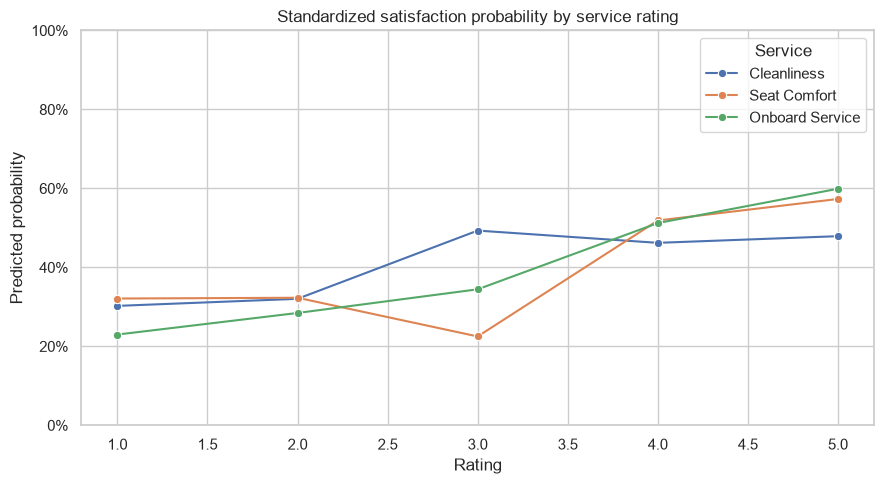

In [5]:
drop_results=[]
for variable, term in zip(h1_vars, service_terms):
    reduced_terms=[t for t in service_terms if t != term]
    reduced=glm("is_satisfied ~ " + " + ".join(reduced_terms), data=h1, family=Binomial()).fit()
    stat, dfd, p=lr_test(h1_full,reduced)
    drop_results.append((variable,stat,dfd,p))
h1_drop=pd.DataFrame(drop_results,columns=["Service","LR statistic","df","Raw p-value"])
h1_drop["Holm p-value"]=multipletests(h1_drop["Raw p-value"],method="holm")[1]
h1_drop["Reject service-level H0"]=h1_drop["Holm p-value"]<ALPHA
display(h1_drop.style.format({"LR statistic":"{:.2f}","Raw p-value":"{:.3e}","Holm p-value":"{:.3e}"}).hide(axis="index"))

h1_prob=[]
for variable in h1_vars:
    table=standardized_probabilities(h1_full,h1,variable,[1,2,3,4,5])
    table.insert(0,"Service",variable.replace("_rating_clean","").replace("_"," ").title())
    h1_prob.append(table)
h1_prob=pd.concat(h1_prob,ignore_index=True)
display(h1_prob.style.format({"Predicted probability":"{:.1%}","CI low":"{:.1%}","CI high":"{:.1%}"}).hide(axis="index"))
fig,ax=plt.subplots(figsize=(9,5))
sns.lineplot(data=h1_prob,x="Level",y="Predicted probability",hue="Service",marker="o",ax=ax)
ax.set(title="Standardized satisfaction probability by service rating",xlabel="Rating",ylabel="Predicted probability",ylim=(0,1));
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1)); plt.tight_layout(); plt.show()

In [6]:
adjusters = "age + C(gender) + C(customer_type) + C(travel_type) + C(travel_class) + np.log1p(flight_distance) + np.log1p(departure_delay)"
h1_adj_formula = h1_formula + " + " + adjusters
h1_adj = glm(h1_adj_formula, data=h1, family=Binomial()).fit()
h1_adj_reduced = glm("is_satisfied ~ " + adjusters, data=h1, family=Binomial()).fit()
h1_adj_lr,h1_adj_df,h1_adj_p=lr_test(h1_adj,h1_adj_reduced)
h1_trend=glm("is_satisfied ~ cleanliness_rating_clean + seat_comfort_rating_clean + onboard_service_rating_clean + " + adjusters,data=h1,family=Binomial()).fit()
h1_sensitivity=glm("is_satisfied ~ cleanliness_rating + seat_comfort_rating + onboard_service_rating",data=df,family=Binomial()).fit()
display(pd.DataFrame([{"Model":"Adjusted categorical service model","N":int(h1_adj.nobs),"LR statistic":h1_adj_lr,"df":h1_adj_df,"p-value":h1_adj_p,"Decision":"Reject H0" if h1_adj_p<ALPHA else "Fail to reject H0"}]).style.format({"N":"{:,}","LR statistic":"{:.2f}","p-value":"{:.3e}"}).hide(axis="index"))
display(Markdown("**Adjusted ordered-trend odds ratios per one-point rating increase**"))
display(odds_ratio_table(h1_trend,"cleanliness_rating_clean|seat_comfort_rating_clean|onboard_service_rating_clean").style.format({"Odds ratio":"{:.2f}","CI low":"{:.2f}","CI high":"{:.2f}","p-value":"{:.3e}"}).hide(axis="index"))
display(pd.DataFrame([model_diagnostics(h1_full,"Primary unadjusted"),model_diagnostics(h1_adj,"Adjusted")]).style.format({"McFadden pseudo-R2":"{:.3f}","Min fitted probability":"{:.4f}","Max fitted probability":"{:.4f}","Deviance/df residual":"{:.3f}"}).hide(axis="index"))

Model,N,LR statistic,df,p-value,Decision
Adjusted categorical service model,"129,861",23777.72,12,0.000e+00,Reject H0


**Adjusted ordered-trend odds ratios per one-point rating increase**

Term,Odds ratio,CI low,CI high,p-value
cleanliness_rating_clean,1.44,1.42,1.46,0.000e+00
seat_comfort_rating_clean,1.32,1.29,1.34,2.370e-242
onboard_service_rating_clean,1.82,1.79,1.84,0.000e+00


Model,N,McFadden pseudo-R2,Converged,Min fitted probability,Max fitted probability,Deviance/df residual
Primary unadjusted,129861,0.189,True,0.0422,0.8151,1.111
Adjusted,129861,0.432,True,0.0007,0.9788,0.777


In [7]:
# Prespecified H1 sensitivity analyses
h1_zero_formula="is_satisfied ~ C(cleanliness_rating) + C(seat_comfort_rating) + C(onboard_service_rating)"
h1_zero=glm(h1_zero_formula,data=df,family=Binomial()).fit(); h1_zero_null=glm("is_satisfied ~ 1",data=df,family=Binomial()).fit()
h1_zero_lr=lr_test(h1_zero,h1_zero_null)
h1_core=glm("is_satisfied ~ core_service_score_clean",data=h1,family=Binomial()).fit(); h1_core_null=glm("is_satisfied ~ 1",data=h1,family=Binomial()).fit(); h1_core_lr=lr_test(h1_core,h1_core_null)
h1_arr_data=h1.dropna(subset=["arrival_delay"]).copy()
h1_arr_adjusters="age + C(gender) + C(customer_type) + C(travel_type) + C(travel_class) + np.log1p(flight_distance) + np.log1p(arrival_delay)"
h1_arr=glm(h1_formula+" + "+h1_arr_adjusters,data=h1_arr_data,family=Binomial()).fit(); h1_arr_reduced=glm("is_satisfied ~ "+h1_arr_adjusters,data=h1_arr_data,family=Binomial()).fit(); h1_arr_lr=lr_test(h1_arr,h1_arr_reduced)
h1_sens=pd.DataFrame([
    {"Sensitivity analysis":"Original zero-inclusive categorical ratings","N":len(df),"LR statistic":h1_zero_lr[0],"df":h1_zero_lr[1],"p-value":h1_zero_lr[2]},
    {"Sensitivity analysis":"Clean core-service score trend","N":len(h1),"LR statistic":h1_core_lr[0],"df":h1_core_lr[1],"p-value":h1_core_lr[2]},
    {"Sensitivity analysis":"Adjusted model using arrival instead of departure delay","N":len(h1_arr_data),"LR statistic":h1_arr_lr[0],"df":h1_arr_lr[1],"p-value":h1_arr_lr[2]},
])
display(Markdown("**H1 sensitivity analyses**")); display(h1_sens.style.format({"N":"{:,}","LR statistic":"{:.2f}","p-value":"{:.3e}"}).hide(axis="index"))

**H1 sensitivity analyses**

Sensitivity analysis,N,LR statistic,df,p-value
Original zero-inclusive categorical ratings,"129,880",33613.27,15,0.000e+00
Clean core-service score trend,"129,861",28086.22,1,0.000e+00
Adjusted model using arrival instead of departure delay,"129,468",23446.92,12,0.000e+00


## 3. Hypothesis 2 — Travel class and satisfaction

**Primary test:** Pearson chi-square test of the 3 × 2 travel-class by satisfaction table. Planned Business-versus-Economy and Business-versus-Economy-Plus proportion comparisons receive Holm correction.

In [8]:
h2_table=pd.crosstab(df["travel_class"],df["satisfaction"]).reindex(["Business","Economy","Economy Plus"])
chi2,p_h2,dof,expected=stats.chi2_contingency(h2_table)
n=h2_table.to_numpy().sum(); cramers_v=np.sqrt(chi2/(n*min(h2_table.shape[0]-1,h2_table.shape[1]-1)))
display(h2_table.style.format("{:,}"))
display(pd.DataFrame([{"N":n,"Chi-square":chi2,"df":dof,"p-value":p_h2,"Minimum expected count":expected.min(),"Cramer's V":cramers_v,"Decision":"Reject H0" if p_h2<ALPHA else "Fail to reject H0"}]).style.format({"N":"{:,}","Chi-square":"{:.2f}","p-value":"{:.3e}","Minimum expected count":"{:.1f}","Cramer's V":"{:.3f}"}).hide(axis="index"))

rates=df.groupby("travel_class").is_satisfied.agg(["sum","count","mean"]).reindex(["Business","Economy","Economy Plus"])
comparisons=[]
raw=[]
for other in ["Economy","Economy Plus"]:
    count=np.array([rates.loc["Business","sum"],rates.loc[other,"sum"]]); obs=np.array([rates.loc["Business","count"],rates.loc[other,"count"]])
    z,p=proportions_ztest(count,obs,alternative="two-sided")
    low,high=confint_proportions_2indep(count[0],obs[0],count[1],obs[1],compare="diff",method="newcomb")
    comparisons.append({"Comparison":f"Business vs {other}","Business rate":rates.loc["Business","mean"],"Other rate":rates.loc[other,"mean"],"Difference":rates.loc["Business","mean"]-rates.loc[other,"mean"],"CI low":low,"CI high":high,"z":z,"Raw p-value":p}); raw.append(p)
h2_contrasts=pd.DataFrame(comparisons); h2_contrasts["Holm p-value"]=multipletests(raw,method="holm")[1]; h2_contrasts["Reject contrast H0"]=h2_contrasts["Holm p-value"]<ALPHA
display(h2_contrasts.style.format({"Business rate":"{:.1%}","Other rate":"{:.1%}","Difference":"{:.1%}","CI low":"{:.1%}","CI high":"{:.1%}","z":"{:.2f}","Raw p-value":"{:.3e}","Holm p-value":"{:.3e}"}).hide(axis="index"))

satisfaction,Neutral or Dissatisfied,Satisfied
travel_class,,
Business,"18,994","43,166"
Economy,"47,366","10,943"
Economy Plus,"7,092","2,319"


N,Chi-square,df,p-value,Minimum expected count,Cramer's V,Decision
"129,880",32906.17,2,0.000e+00,4088.7,0.503,Reject H0


Comparison,Business rate,Other rate,Difference,CI low,CI high,z,Raw p-value,Holm p-value,Reject contrast H0
Business vs Economy,69.4%,18.8%,50.7%,50.2%,51.2%,176.72,0.000e+00,0.000e+00,True
Business vs Economy Plus,69.4%,24.6%,44.8%,43.8%,45.7%,84.16,0.000e+00,0.000e+00,True


In [9]:
h2_formula="is_satisfied ~ C(travel_class, Treatment(reference='Business')) + age + C(gender) + C(customer_type) + C(travel_type) + np.log1p(flight_distance) + np.log1p(departure_delay)"
h2_adj=glm(h2_formula,data=df,family=Binomial()).fit()
h2_reduced=glm("is_satisfied ~ age + C(gender) + C(customer_type) + C(travel_type) + np.log1p(flight_distance) + np.log1p(departure_delay)",data=df,family=Binomial()).fit()
h2_lr,h2_df,h2_p=lr_test(h2_adj,h2_reduced)
h2_probs=standardized_probabilities(h2_adj,df,"travel_class",["Business","Economy Plus","Economy"])
display(pd.DataFrame([{"Adjusted-model N":int(h2_adj.nobs),"Class LR statistic":h2_lr,"df":h2_df,"p-value":h2_p,"Decision":"Reject H0" if h2_p<ALPHA else "Fail to reject H0"}]).style.format({"Adjusted-model N":"{:,}","Class LR statistic":"{:.2f}","p-value":"{:.3e}"}).hide(axis="index"))
display(Markdown("**Adjusted class odds ratios (reference = Business)**")); display(odds_ratio_table(h2_adj,"travel_class").style.format({"Odds ratio":"{:.2f}","CI low":"{:.2f}","CI high":"{:.2f}","p-value":"{:.3e}"}).hide(axis="index"))
display(Markdown("**Standardized adjusted satisfaction probabilities**")); display(h2_probs.style.format({"Predicted probability":"{:.1%}","CI low":"{:.1%}","CI high":"{:.1%}"}).hide(axis="index"))
display(pd.DataFrame([model_diagnostics(h2_adj,"Adjusted class model")]).style.format({"McFadden pseudo-R2":"{:.3f}","Min fitted probability":"{:.4f}","Max fitted probability":"{:.4f}","Deviance/df residual":"{:.3f}"}).hide(axis="index"))

Adjusted-model N,Class LR statistic,df,p-value,Decision
"129,880",6023.56,2,0.000e+00,Reject H0


**Adjusted class odds ratios (reference = Business)**

Term,Odds ratio,CI low,CI high,p-value
"C(travel_class, Treatment(reference='Business'))[T.Economy]",0.28,0.27,0.29,0.000e+00
"C(travel_class, Treatment(reference='Business'))[T.Economy Plus]",0.24,0.23,0.26,0.000e+00


**Standardized adjusted satisfaction probabilities**

Level,Predicted probability,CI low,CI high
Business,54.4%,54.0%,54.9%
Economy Plus,28.4%,27.5%,29.3%
Economy,30.9%,30.4%,31.3%


Model,N,McFadden pseudo-R2,Converged,Min fitted probability,Max fitted probability,Deviance/df residual
Adjusted class model,129880,0.298,True,0.0096,0.8119,0.960


In [10]:
# Prespecified H2 sensitivity and subgroup analyses
h2_arr_data=df.dropna(subset=["arrival_delay"]).copy()
h2_arr_formula="is_satisfied ~ C(travel_class, Treatment(reference='Business')) + age + C(gender) + C(customer_type) + C(travel_type) + np.log1p(flight_distance) + np.log1p(arrival_delay)"
h2_arr=glm(h2_arr_formula,data=h2_arr_data,family=Binomial()).fit(); h2_arr_reduced=glm("is_satisfied ~ age + C(gender) + C(customer_type) + C(travel_type) + np.log1p(flight_distance) + np.log1p(arrival_delay)",data=h2_arr_data,family=Binomial()).fit(); h2_arr_lr=lr_test(h2_arr,h2_arr_reduced)
h2_subgroups=[]
for grouping,level in [("travel_type","Business"),("travel_type","Personal"),("customer_type","Returning"),("customer_type","First-time")]:
    subset=df[df[grouping]==level]; tab=pd.crosstab(subset.travel_class,subset.satisfaction); stat,p,dof,_=stats.chi2_contingency(tab)
    h2_subgroups.append({"Stratum":f"{grouping} = {level}","N":len(subset),"Chi-square":stat,"df":dof,"p-value":p})
display(Markdown("**H2 arrival-delay sensitivity**")); display(pd.DataFrame([{"Analysis":"Adjusted class model using arrival instead of departure delay","N":len(h2_arr_data),"LR statistic":h2_arr_lr[0],"df":h2_arr_lr[1],"p-value":h2_arr_lr[2]}]).style.format({"N":"{:,}","LR statistic":"{:.2f}","p-value":"{:.3e}"}).hide(axis="index"))
display(Markdown("**Prespecified stratified global class comparisons**")); display(pd.DataFrame(h2_subgroups).style.format({"N":"{:,}","Chi-square":"{:.2f}","p-value":"{:.3e}"}).hide(axis="index"))

**H2 arrival-delay sensitivity**

Analysis,N,LR statistic,df,p-value
Adjusted class model using arrival instead of departure delay,"129,487",5937.34,2,0.000e+00


**Prespecified stratified global class comparisons**

Stratum,N,Chi-square,df,p-value
travel_type = Business,"89,693",13721.45,2,0.000e+00
travel_type = Personal,"40,187",17.07,2,1.961e-04
customer_type = Returning,"106,100",30571.83,2,0.000e+00
customer_type = First-time,"23,780",2060.42,2,0.000e+00


## 4. Hypothesis 3 — Flight delays and satisfaction

Departure and arrival delay are tested separately. A natural cubic spline with fixed knots at 15, 60, and 180 dataset units is compared with a linear form. The spline is retained if its additional nonlinear terms improve fit at α = 0.05. Holm correction is applied across the two primary delay tests.

In [11]:
def delay_models(data, variable):
    linear=glm(f"is_satisfied ~ {variable}",data=data,family=Binomial()).fit()
    spline=glm(f"is_satisfied ~ cr({variable}, knots=(15,60,180), constraints='center')",data=data,family=Binomial()).fit()
    null=glm("is_satisfied ~ 1",data=data,family=Binomial()).fit()
    nonlin=lr_test(spline,linear); global_test=lr_test(spline,null)
    return linear,spline,nonlin,global_test

h3_dep=df.dropna(subset=["departure_delay","is_satisfied"]).copy()
h3_arr=df.dropna(subset=["arrival_delay","is_satisfied"]).copy()
dep_lin,dep_spline,dep_nonlin,dep_global=delay_models(h3_dep,"departure_delay")
arr_lin,arr_spline,arr_nonlin,arr_global=delay_models(h3_arr,"arrival_delay")
h3_shape=pd.DataFrame([
    {"Exposure":"Departure delay","N":len(h3_dep),"Nonlinearity LR":dep_nonlin[0],"df":dep_nonlin[1],"Nonlinearity p":dep_nonlin[2],"Selected form":"Spline" if dep_nonlin[2]<ALPHA else "Linear"},
    {"Exposure":"Arrival delay","N":len(h3_arr),"Nonlinearity LR":arr_nonlin[0],"df":arr_nonlin[1],"Nonlinearity p":arr_nonlin[2],"Selected form":"Spline" if arr_nonlin[2]<ALPHA else "Linear"}
])
display(h3_shape.style.format({"N":"{:,}","Nonlinearity LR":"{:.2f}","Nonlinearity p":"{:.3e}"}).hide(axis="index"))
selected=[dep_spline if dep_nonlin[2]<ALPHA else dep_lin,arr_spline if arr_nonlin[2]<ALPHA else arr_lin]
global_values=[dep_global if dep_nonlin[2]<ALPHA else lr_test(dep_lin,glm("is_satisfied ~ 1",data=h3_dep,family=Binomial()).fit()),arr_global if arr_nonlin[2]<ALPHA else lr_test(arr_lin,glm("is_satisfied ~ 1",data=h3_arr,family=Binomial()).fit())]
h3_primary=pd.DataFrame([{"Exposure":"Departure delay","N":len(h3_dep),"LR statistic":global_values[0][0],"df":global_values[0][1],"Raw p-value":global_values[0][2]}, {"Exposure":"Arrival delay","N":len(h3_arr),"LR statistic":global_values[1][0],"df":global_values[1][1],"Raw p-value":global_values[1][2]}])
h3_primary["Holm p-value"]=multipletests(h3_primary["Raw p-value"],method="holm")[1]; h3_primary["Decision"]=np.where(h3_primary["Holm p-value"]<ALPHA,"Reject H0","Fail to reject H0")
display(h3_primary.style.format({"N":"{:,}","LR statistic":"{:.2f}","Raw p-value":"{:.3e}","Holm p-value":"{:.3e}"}).hide(axis="index"))

Exposure,N,Nonlinearity LR,df,Nonlinearity p,Selected form
Departure delay,"129,880",365.28,3,7.321e-79,Spline
Arrival delay,"129,487",910.52,3,4.631e-197,Spline


Exposure,N,LR statistic,df,Raw p-value,Holm p-value,Decision
Departure delay,"129,880",721.82,4,6.580e-155,6.580e-155,Reject H0
Arrival delay,"129,487",1384.49,4,1.591e-298,3.182e-298,Reject H0


Delay type,Level,Predicted probability,CI low,CI high,Difference vs 0
Departure,0,45.9%,45.6%,46.3%,+0.0%
Departure,15,40.4%,39.9%,41.0%,-5.5%
Departure,30,37.3%,36.6%,38.0%,-8.6%
Departure,60,35.8%,35.1%,36.6%,-10.1%
Departure,120,35.8%,34.6%,36.9%,-10.2%
Arrival,0,47.2%,46.8%,47.5%,+0.0%
Arrival,15,37.7%,37.2%,38.2%,-9.5%
Arrival,30,33.5%,32.9%,34.2%,-13.6%
Arrival,60,34.7%,34.0%,35.4%,-12.5%
Arrival,120,37.7%,36.5%,38.9%,-9.5%


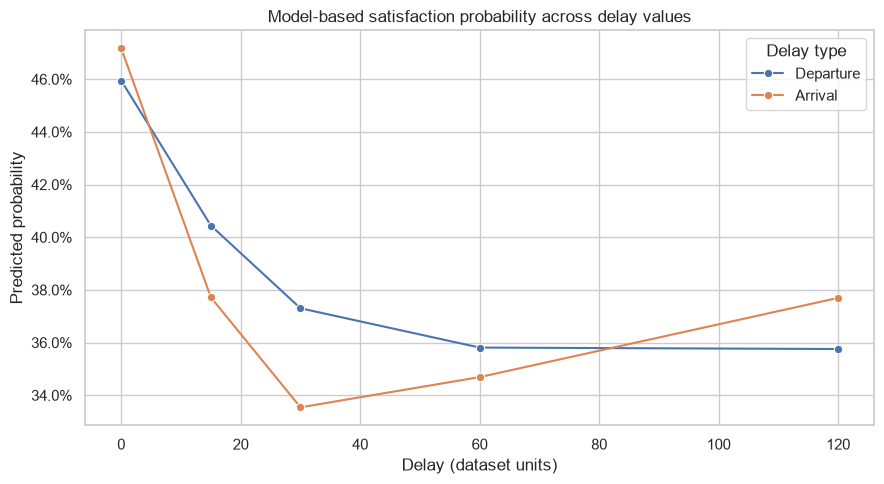

In [12]:
delay_values=[0,15,30,60,120]
delay_predictions=[]
for label,data,variable,model in [("Departure",h3_dep,"departure_delay",selected[0]),("Arrival",h3_arr,"arrival_delay",selected[1])]:
    pred=standardized_probabilities(model,data,variable,delay_values); pred.insert(0,"Delay type",label); delay_predictions.append(pred)
delay_predictions=pd.concat(delay_predictions,ignore_index=True)
delay_predictions["Difference vs 0"] = delay_predictions.groupby("Delay type")["Predicted probability"].transform(lambda x:x-x.iloc[0])
display(delay_predictions.style.format({"Predicted probability":"{:.1%}","CI low":"{:.1%}","CI high":"{:.1%}","Difference vs 0":"{:+.1%}"}).hide(axis="index"))
fig,ax=plt.subplots(figsize=(9,5)); sns.lineplot(data=delay_predictions,x="Level",y="Predicted probability",hue="Delay type",marker="o",ax=ax)
ax.set(title="Model-based satisfaction probability across delay values",xlabel="Delay (dataset units)",ylabel="Predicted probability"); ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1)); plt.tight_layout(); plt.show()

In [13]:
adjustment="age + C(gender) + C(customer_type) + C(travel_type) + C(travel_class) + np.log1p(flight_distance)"
adjusted_results=[]; adjusted_models={}
for label,data,variable,use_spline in [("Departure delay",h3_dep,"departure_delay",dep_nonlin[2]<ALPHA),("Arrival delay",h3_arr,"arrival_delay",arr_nonlin[2]<ALPHA)]:
    term=f"cr({variable}, knots=(15,60,180), constraints='center')" if use_spline else variable
    full=glm(f"is_satisfied ~ {term} + {adjustment}",data=data,family=Binomial()).fit()
    reduced=glm(f"is_satisfied ~ {adjustment}",data=data,family=Binomial()).fit()
    stat,dfd,p=lr_test(full,reduced); adjusted_models[label]=full
    adjusted_results.append({"Exposure":label,"N":int(full.nobs),"LR statistic":stat,"df":dfd,"Raw p-value":p})
h3_adjusted=pd.DataFrame(adjusted_results); h3_adjusted["Holm p-value"]=multipletests(h3_adjusted["Raw p-value"],method="holm")[1]; h3_adjusted["Decision"]=np.where(h3_adjusted["Holm p-value"]<ALPHA,"Reject H0","Fail to reject H0")
display(h3_adjusted.style.format({"N":"{:,}","LR statistic":"{:.2f}","Raw p-value":"{:.3e}","Holm p-value":"{:.3e}"}).hide(axis="index"))

adj_predictions=[]
for label,data,variable in [("Departure delay",h3_dep,"departure_delay"),("Arrival delay",h3_arr,"arrival_delay")]:
    pred=standardized_probabilities(adjusted_models[label],data,variable,delay_values); pred.insert(0,"Exposure",label); adj_predictions.append(pred)
adj_predictions=pd.concat(adj_predictions,ignore_index=True); adj_predictions["Difference vs 0"]=adj_predictions.groupby("Exposure")["Predicted probability"].transform(lambda x:x-x.iloc[0])
display(adj_predictions.style.format({"Predicted probability":"{:.1%}","CI low":"{:.1%}","CI high":"{:.1%}","Difference vs 0":"{:+.1%}"}).hide(axis="index"))
display(pd.DataFrame([model_diagnostics(adjusted_models[k],f"Adjusted {k}") for k in adjusted_models]).style.format({"McFadden pseudo-R2":"{:.3f}","Min fitted probability":"{:.4f}","Max fitted probability":"{:.4f}","Deviance/df residual":"{:.3f}"}).hide(axis="index"))

Exposure,N,LR statistic,df,Raw p-value,Holm p-value,Decision
Departure delay,"129,880",1083.87,4,2.372e-233,2.372e-233,Reject H0
Arrival delay,"129,487",1978.29,4,0.000e+00,0.000e+00,Reject H0


Exposure,Level,Predicted probability,CI low,CI high,Difference vs 0
Departure delay,0,45.9%,45.7%,46.2%,+0.0%
Departure delay,15,40.3%,39.8%,40.7%,-5.7%
Departure delay,30,37.1%,36.6%,37.6%,-8.8%
Departure delay,60,36.2%,35.6%,36.8%,-9.7%
Departure delay,120,36.7%,35.7%,37.6%,-9.2%
Arrival delay,0,47.0%,46.7%,47.3%,+0.0%
Arrival delay,15,37.8%,37.4%,38.3%,-9.2%
Arrival delay,30,33.7%,33.2%,34.2%,-13.3%
Arrival delay,60,35.4%,34.8%,36.0%,-11.6%
Arrival delay,120,38.7%,37.8%,39.7%,-8.3%


Model,N,McFadden pseudo-R2,Converged,Min fitted probability,Max fitted probability,Deviance/df residual
Adjusted Departure delay,129880,0.299,True,0.0093,0.8106,0.960
Adjusted Arrival delay,129487,0.304,True,0.0079,0.8237,0.953


In [14]:
band_results=[]
for variable,reference in [("departure_delay_band","No delay"),("arrival_delay_band","No delay")]:
    data=df if variable=="departure_delay_band" else df[df[variable]!="Missing"]
    model=glm(f"is_satisfied ~ C({variable}, Treatment(reference='{reference}'))",data=data,family=Binomial()).fit()
    table=odds_ratio_table(model,variable); table.insert(0,"Exposure",variable); band_results.append(table)
display(pd.concat(band_results,ignore_index=True).style.format({"Odds ratio":"{:.2f}","CI low":"{:.2f}","CI high":"{:.2f}","p-value":"{:.3e}"}).hide(axis="index"))

Exposure,Term,Odds ratio,CI low,CI high,p-value
departure_delay_band,"C(departure_delay_band, Treatment(reference='No delay'))[T.Long (>60)]",0.66,0.63,0.69,1.022e-72
departure_delay_band,"C(departure_delay_band, Treatment(reference='No delay'))[T.Moderate (16-60)]",0.71,0.68,0.73,3.004e-99
departure_delay_band,"C(departure_delay_band, Treatment(reference='No delay'))[T.Short (1-15)]",0.91,0.88,0.93,8.799e-12
arrival_delay_band,"C(arrival_delay_band, Treatment(reference='No delay'))[T.Long (>60)]",0.61,0.59,0.64,1.369e-99
arrival_delay_band,"C(arrival_delay_band, Treatment(reference='No delay'))[T.Moderate (16-60)]",0.62,0.60,0.64,9.063e-187
arrival_delay_band,"C(arrival_delay_band, Treatment(reference='No delay'))[T.Short (1-15)]",0.78,0.76,0.80,8.068e-69


In [15]:
# Prespecified H3 sensitivity analyses
h3_sensitivity=[]
for label,data,variable in [("Departure",h3_dep,"departure_delay"),("Arrival",h3_arr,"arrival_delay")]:
    null=glm("is_satisfied ~ 1",data=data,family=Binomial()).fit()
    log_model=glm(f"is_satisfied ~ np.log1p({variable})",data=data,family=Binomial()).fit(); log_lr=lr_test(log_model,null)
    cap=data[variable].quantile(.99); capped=data.copy(); capped[f"{variable}_winsor99"]=capped[variable].clip(upper=cap)
    cap_model=glm(f"is_satisfied ~ {variable}_winsor99",data=capped,family=Binomial()).fit(); cap_null=glm("is_satisfied ~ 1",data=capped,family=Binomial()).fit(); cap_lr=lr_test(cap_model,cap_null)
    h3_sensitivity.extend([
        {"Exposure":label,"Sensitivity":"log1p transformation","N":len(data),"LR statistic":log_lr[0],"df":log_lr[1],"p-value":log_lr[2]},
        {"Exposure":label,"Sensitivity":f"99th-percentile winsorized (cap={cap:.0f})","N":len(data),"LR statistic":cap_lr[0],"df":cap_lr[1],"p-value":cap_lr[2]},
    ])
arrival_missing_model=glm("is_satisfied ~ C(arrival_delay_band, Treatment(reference='No delay'))",data=df,family=Binomial()).fit()
arrival_missing_or=odds_ratio_table(arrival_missing_model,"Missing")
display(pd.DataFrame(h3_sensitivity).style.format({"N":"{:,}","LR statistic":"{:.2f}","p-value":"{:.3e}"}).hide(axis="index"))
display(Markdown("**Arrival-delay Missing category versus No delay**")); display(arrival_missing_or.style.format({"Odds ratio":"{:.2f}","CI low":"{:.2f}","CI high":"{:.2f}","p-value":"{:.3e}"}).hide(axis="index"))

Exposure,Sensitivity,N,LR statistic,df,p-value
Departure,log1p transformation,"129,880",674.80,1,9.028e-149
Departure,99th-percentile winsorized (cap=180),"129,880",460.13,1,4.514e-102
Arrival,log1p transformation,"129,487",1356.39,1,6.294e-297
Arrival,99th-percentile winsorized (cap=182),"129,487",621.79,1,3.053e-137


**Arrival-delay Missing category versus No delay**

Term,Odds ratio,CI low,CI high,p-value
"C(arrival_delay_band, Treatment(reference='No delay'))[T.Missing]",0.81,0.66,0.99,4.109e-02


## 5. Decision summary and interpretation

In [16]:
summary=pd.DataFrame([
    {"Hypothesis":"H1: Service quality","Primary p-value":h1_p,"Decision":"Reject H0" if h1_p<ALPHA else "Fail to reject H0"},
    {"Hypothesis":"H2: Travel class","Primary p-value":p_h2,"Decision":"Reject H0" if p_h2<ALPHA else "Fail to reject H0"},
    {"Hypothesis":"H3a: Departure delay","Primary p-value":h3_primary.loc[0,"Holm p-value"],"Decision":h3_primary.loc[0,"Decision"]},
    {"Hypothesis":"H3b: Arrival delay","Primary p-value":h3_primary.loc[1,"Holm p-value"],"Decision":h3_primary.loc[1,"Decision"]},
])
display(summary.style.format({"Primary p-value":"{:.3e}"}).hide(axis="index"))
display(Markdown("""
- Rejecting a null hypothesis indicates evidence of an association in this dataset; it does not demonstrate causation.
- Effect sizes and predicted-probability differences should guide business interpretation because the large sample can make small effects statistically significant.
- Adjusted models address observed covariates only. Unmeasured factors such as route, fare, aircraft, loyalty tier, and disruption cause can still confound results.
- `Neutral or Dissatisfied` is a combined outcome and cannot distinguish neutral from actively dissatisfied passengers.
"""))

Hypothesis,Primary p-value,Decision
H1: Service quality,0.000e+00,Reject H0
H2: Travel class,0.000e+00,Reject H0
H3a: Departure delay,6.580e-155,Reject H0
H3b: Arrival delay,3.182e-298,Reject H0



- Rejecting a null hypothesis indicates evidence of an association in this dataset; it does not demonstrate causation.
- Effect sizes and predicted-probability differences should guide business interpretation because the large sample can make small effects statistically significant.
- Adjusted models address observed covariates only. Unmeasured factors such as route, fare, aircraft, loyalty tier, and disruption cause can still confound results.
- `Neutral or Dissatisfied` is a combined outcome and cannot distinguish neutral from actively dissatisfied passengers.
